In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
#coffea output file
f_sig = "../coffea/new_signal_2022/match_new.coffea"
#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
print (sig_histo.keys())

dict_keys(['gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])


Saved: ./plots//gen_ele_pT.png
Count: [1106. 1598. 3124. 3085. 2419. 1832. 1338.  995.  671.  445.  288.  214.
  137.   98.   62.  117.   31.    8.]
Edges: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 20. 30.
 50.]
bins_x_den: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 17.5 25.  40. ]
indices having element 0: (array([], dtype=int64),)
Denominator: [1106. 1598. 3124. 3085. 2419. 1832. 1338.  995.  671.  445.  288.  214.
  137.   98.   62.  117.   31.    8.]
bins: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 17.5 25.  40. ]


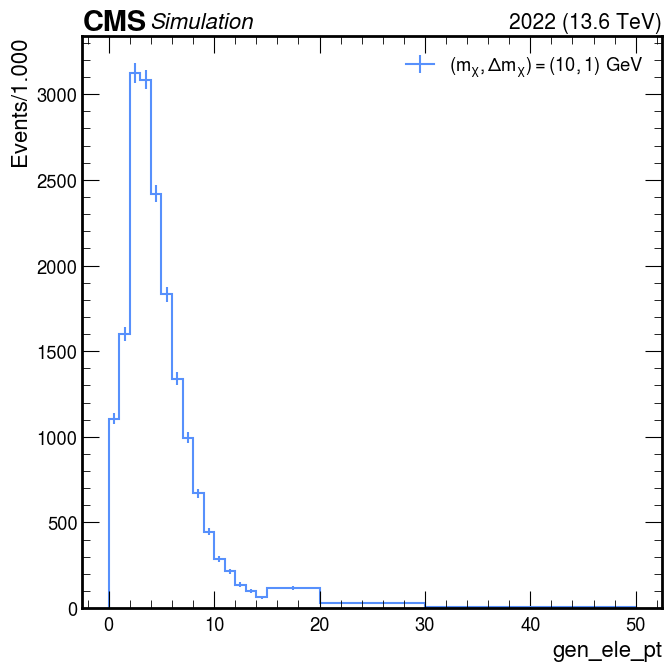

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'gen_ele_pT.png'
}

count_den, edges_den = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)
# h_den = np.array(h_den)
print ("Count:", count_den)
print ("Edges:", edges_den)

bins_x_den = (edges_den[:-1] + edges_den[1:])*(0.5)
print ("bins_x_den:", bins_x_den)


count_den = np.array(count_den)

indices = np.where(count_den == 0)
print ("indices having element 0:" , indices)

deno = count_den[count_den != 0]  #IMP
print ("Denominator:", deno)  


########################################

edges_den = np.array(bins_x_den)

bins_deno = np.delete(edges_den,indices ) #IMP

print ("bins:",bins_deno)


TypeError: plot_signal_1D() got an unexpected keyword argument 'match_type'

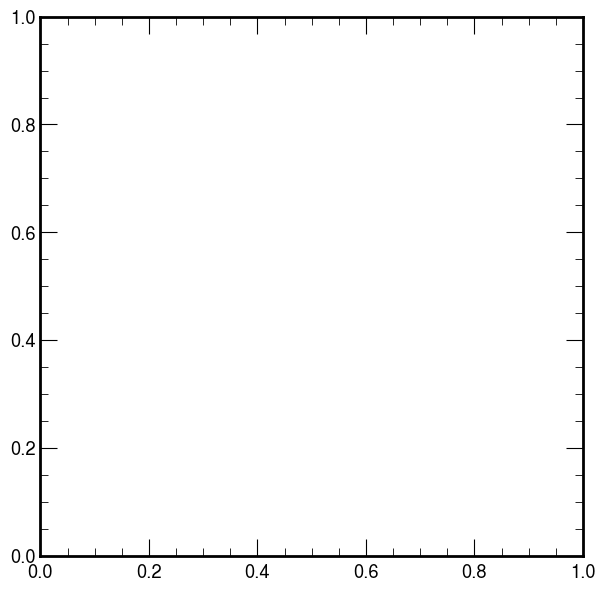

In [4]:
m1=10
delta = 0.1
ctau = 10
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "pT of gen electrons(matched to 'R')",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'match_ele_gen_pt.png'
}
count_num, edges_num = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)

print ("Count:", count_num)
print ("Edges:", edges_num)

bins_x_num = (edges_num[:-1] + edges_num[1:])*(0.5)
print ("bins_x_num:", bins_x_num)


count_num = np.array(count_num)
num = np.delete(count_num, indices)
print ("num:", num)



edges_num = np.array(bins_x_num)

bins_num = np.delete(edges_num, indices) #IMP

print ("bins:",bins_num)

print(np.array_equal(bins_num, bins_deno))


In [ ]:
print ("numerator:",num) 
print ("denominator;", deno)

eff = np.divide(num,deno)
print(eff)

In [ ]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency, unc_eff = eff_determine_unc(num, deno)
print ("Efficiency:",efficiency)
print ("unc-eff:", unc_eff)
yerr = [unc_eff[0], unc_eff[1]]
# print ("yerr:",yerr)

In [ ]:
# plt.errorbar(bins_deno, efficiency, yerr , fmt='o', label = '(m1, dm)=(10,1) GeV', color = 'green')
# #plt.step(bins_deno, efficiency, yerr )

# # plt.step(bins_deno, efficiency, color='orange')
# # plt.errorbar(bins_deno, efficiency, yerr , fmt='o', color='black')


# plt.xlabel("pT (in GeV)")
# plt.ylabel("Electron Reconstruction Efficiency")
# plt.title ("ctau = 10mm, 10% mass splitting")
# plt.legend(["Low-pT"],loc='upper right')
# plt.savefig("Electron_Reconstruction_Eff_lowpT.png")

In [ ]:
plt.errorbar(bins_deno, efficiency, yerr , fmt='o', label = '(m1, dm)=(10,1) GeV')
#plt.step(bins_deno, efficiency, yerr )

# plt.step(bins_deno, efficiency, color='orange')
# plt.errorbar(bins_deno, efficiency, yerr , fmt='o', color='black')


plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title ("m1 = 10 GeV, 10% mass splitting, ctau = 10mm")
plt.legend(["GED"],loc='upper left')
plt.savefig("Electron_Reconstruction_Eff_GED_pT.png")

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'gen_ele_pT.png'
}

count_den, edges_den = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)
# h_den = np.array(h_den)
print ("Count:", count_den)
print ("Edges:", edges_den)

bins_x_den = (edges_den[:-1] + edges_den[1:])*(0.5)
print ("bins_x_den:", bins_x_den)


count_den = np.array(count_den)

indices = np.where(count_den == 0)
print ("indices having element 0:" , indices)

deno = count_den[count_den != 0]  #IMP
print ("Denominator:", deno)  


########################################

edges_den = np.array(bins_x_den)

bins_deno = np.delete(edges_den,indices ) #IMP

print ("bins:",bins_deno)


In [ ]:
m1=10
delta = 0.1
ctau = 10
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "pT of gen electrons(matched to 'R')",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'match_ele_gen_pt.png'
}
count_num, edges_num = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)

print ("Count:", count_num)
print ("Edges:", edges_num)

bins_x_num = (edges_num[:-1] + edges_num[1:])*(0.5)
print ("bins_x_num:", bins_x_num)


count_num = np.array(count_num)
num = np.delete(count_num, indices)
print ("num:", num)



edges_num = np.array(bins_x_num)

bins_num = np.delete(edges_num, indices) #IMP

print ("bins:",bins_num)

print(np.array_equal(bins_num, bins_deno))


In [ ]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency, unc_eff = eff_determine_unc(num, deno)
print ("Efficiency:",efficiency)
print ("unc-eff:", unc_eff)
yerr = [unc_eff[0], unc_eff[1]]
# print ("yerr:",yerr)

In [ ]:
plt.errorbar(bins_deno, efficiency, yerr , fmt='o', label = '(m1, dm)=(10,1) GeV', color = 'green')
#plt.step(bins_deno, efficiency, yerr )

# plt.step(bins_deno, efficiency, color='orange')
# plt.errorbar(bins_deno, efficiency, yerr , fmt='o', color='black')


plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend(["Low pT"],loc='upper right')
plt.savefig("Electron_Reconstruction_Eff_LowpT_pT.png")
#cross cleaning ntuplizer
#x bins